## Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.models.hull_white import HullWhiteModel
from src.pricing.swaption_pricer import (
    payer_swaption_price,
)
from src.calibration.optimizers import calibrate_hull_white_swaption_surface
from src.calibration.objective import hull_white_swaption_surface_mse_loss

## Parameters

In [2]:
rate = 0.03
strike = 0.03
payment_frequency = 1

option_maturities = np.array([1.0, 2.0, 3.0, 5.0])
swap_maturities = np.array([5.0, 7.0, 10.0])

## Model

In [3]:
true_model = HullWhiteModel(
    mean_reversion=0.05,
    volatility=0.01,
)

true_model

HullWhiteModel(mean_reversion=0.05, volatility=0.01)

## Surface generic

In [4]:
market_prices = np.zeros(
    (len(option_maturities), len(swap_maturities))
)

for i, option_maturity in enumerate(option_maturities):
    for j, swap_maturity in enumerate(swap_maturities):
        if swap_maturity <= option_maturity:
            market_prices[i, j] = np.nan
            continue

        market_prices[i, j] = payer_swaption_price(
            strike=strike,
            option_maturity=option_maturity,
            swap_maturity=swap_maturity,
            rate=rate,
            model=true_model,
            payment_frequency=payment_frequency,
        )

In [5]:
np.random.seed(42)

noise = np.random.normal(
    loc=0.0,
    scale=0.00001,
    size=market_prices.shape,
)

synthetic_market_prices = market_prices + noise
synthetic_market_prices = np.where(
    np.isnan(market_prices),
    np.nan,
    synthetic_market_prices,
)

In [6]:
market_df = pd.DataFrame(
    synthetic_market_prices,
    index=[f"{int(t)}Y" for t in option_maturities],
    columns=[f"{int(t)}Y" for t in swap_maturities],
)

market_df

,5Y,7Y,10Y
1Y,0.002497,0.004533,0.008292
2Y,0.001919,0.004168,0.008659
3Y,0.001135,0.003246,0.007884
5Y,NaN,0.001177,0.005116


## Calibration

In [7]:
calibrated_model = calibrate_hull_white_swaption_surface(
    option_maturities=option_maturities,
    swap_maturities=swap_maturities,
    market_prices=synthetic_market_prices,
    strike=strike,
    rate=rate,
    payment_frequency=payment_frequency,
    initial_guess=(0.03, 0.008),
)

calibrated_model

HullWhiteModel(mean_reversion=0.029955443542116055, volatility=0.009140667148764115)

## Comparison

In [8]:
comparison = pd.DataFrame({
    "parameter": ["mean_reversion", "volatility"],
    "true": [
        true_model.mean_reversion,
        true_model.volatility,
    ],
    "calibrated": [
        calibrated_model.mean_reversion,
        calibrated_model.volatility,
    ],
})

comparison["absolute_error"] = (
    comparison["calibrated"] - comparison["true"]
).abs()

comparison

,parameter,true,calibrated,absolute_error
0,mean_reversion,0.05,0.029955,0.020045
1,volatility,0.01,0.009141,0.000859


In [9]:
calibrated_prices = np.zeros_like(synthetic_market_prices)

for i, option_maturity in enumerate(option_maturities):
    for j, swap_maturity in enumerate(swap_maturities):
        if np.isnan(synthetic_market_prices[i, j]):
            calibrated_prices[i, j] = np.nan
            continue

        calibrated_prices[i, j] = payer_swaption_price(
            strike=strike,
            option_maturity=option_maturity,
            swap_maturity=swap_maturity,
            rate=rate,
            model=calibrated_model,
            payment_frequency=payment_frequency,
        )

## Metrics

In [10]:
residuals = calibrated_prices - synthetic_market_prices

rmse = np.sqrt(np.nanmean(residuals**2))
mae = np.nanmean(np.abs(residuals))
max_abs_error = np.nanmax(np.abs(residuals))

metrics = pd.DataFrame({
    "metric": ["RMSE", "MAE", "Max Absolute Error"],
    "value": [rmse, mae, max_abs_error],
})

metrics

,metric,value
0,RMSE,0.000048
1,MAE,0.000045
2,Max Absolute Error,0.000066


## residuals

In [11]:
residuals_df = pd.DataFrame(
    residuals,
    index=[f"{int(t)}Y" for t in option_maturities],
    columns=[f"{int(t)}Y" for t in swap_maturities],
)

residuals_df

,5Y,7Y,10Y
1Y,-0.000061,-0.000066,0.000024
2Y,-0.000060,-0.000062,0.000041
3Y,-0.000039,-0.000058,0.000043
5Y,NaN,-0.000011,0.000027


## Plots

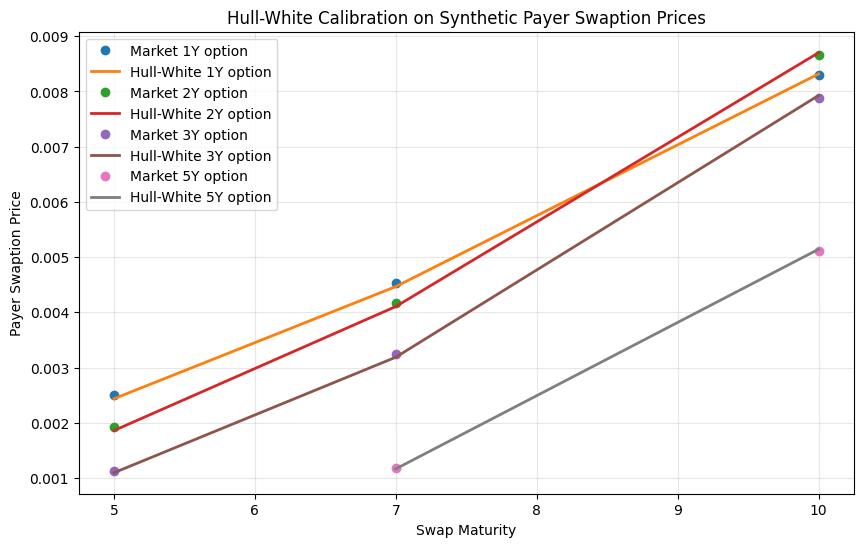

In [12]:
plt.figure(figsize=(10, 6))

for i, option_maturity in enumerate(option_maturities):
    valid_mask = ~np.isnan(synthetic_market_prices[i])

    plt.plot(
        swap_maturities[valid_mask],
        synthetic_market_prices[i, valid_mask],
        marker="o",
        linestyle="",
        label=f"Market {int(option_maturity)}Y option",
    )

    plt.plot(
        swap_maturities[valid_mask],
        calibrated_prices[i, valid_mask],
        linewidth=2,
        label=f"Hull-White {int(option_maturity)}Y option",
    )

plt.title("Hull-White Calibration on Synthetic Payer Swaption Prices")
plt.xlabel("Swap Maturity")
plt.ylabel("Payer Swaption Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

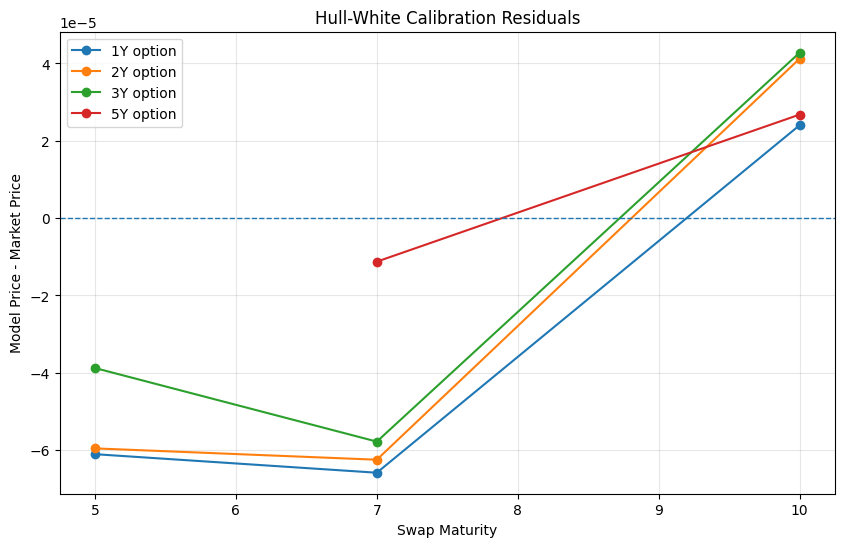

In [15]:
plt.figure(figsize=(10, 6))

for i, option_maturity in enumerate(option_maturities):
    valid_mask = ~np.isnan(residuals[i])

    plt.plot(
        swap_maturities[valid_mask],
        residuals[i, valid_mask],
        marker="o",
        label=f"{int(option_maturity)}Y option",
    )

plt.axhline(0.0, linestyle="--", linewidth=1)

plt.title("Hull-White Calibration Residuals")
plt.xlabel("Swap Maturity")
plt.ylabel("Model Price - Market Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Conclusion

This notebook validates the Hull-White calibration pipeline on a synthetic payer swaption price surface.

Synthetic swaption prices were generated from known Hull-White parameters and then perturbed with small Gaussian noise. The calibration procedure was then used to recover the mean-reversion and volatility parameters.

The calibrated model reproduces the synthetic swaption surface with low pricing errors. This validates the implementation of the Hull-White pricing components, the swaption approximation, and the calibration objective.

This synthetic experiment is an important validation step before applying the model to real interest-rate derivative market data.